In [109]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

comp = pd.read_csv("data/comp trial 1.csv", low_memory=False)
fjc = pd.read_csv("data/fjc trial 1.csv", low_memory=False)

#print(comp.shape, fjc.shape)
#print(comp.head())
#print(fjc.head())

In [110]:
comp["datadate"] = pd.to_datetime(comp["datadate"], dayfirst=True, errors="coerce")
fjc["FILEDATE"] = pd.to_datetime(fjc["FILEDATE"], dayfirst=True, errors="coerce")
#comp["datadate"].head()

In [111]:
comp = comp[(comp["datadate"] >= "2000-01-01") & (comp["datadate"] <= "2018-12-31")]
fjc = fjc[(fjc["FILEDATE"] >= "2000-01-01") & (fjc["FILEDATE"] <= "2019-12-31")]

In [112]:
comp["cik"] = pd.to_numeric(comp["cik"], errors="coerce")
fjc["cik"] = pd.to_numeric(fjc["cik"], errors="coerce")

comp = comp.dropna(subset=["cik"]).copy()
fjc = fjc.dropna(subset=["cik"]).copy()

comp["cik"] = comp["cik"].astype(int)
fjc["cik"] = fjc["cik"].astype(int)

merged = comp.merge(fjc[["cik", "FILEDATE"]], on="cik", how="left")
#merge comp and add the cik and filedate columns for all shared cik values, using a left join to keep all rows from comp and add matching rows from fjc.
merged["days"] = (merged["FILEDATE"] - merged["datadate"]).dt.days
#calculate a new column "days" that shows the difference in days between the filiing date (bankruptcy) and the datadate (company's fisical year end date). 
#Positive days means the filing date is after the data date; negative means it's before.
merged["distress"] = ((merged["days"] > 0) & (merged["days"] <= 365)).astype(int)
#create a new column "distress" that is True (1) if both conditions are met: the filing date is after the data date and within 365 days, otherwise False (0).
merged.loc[merged["FILEDATE"].isna(), "distress"] = 0
#set distress to 0 for rows where FILEDATE is NaN, meaning there is no filing date available.
#loc is used here to acess the filedate column and then check (.isna()) if the value is NaN (returns True), and then explicitly sets the distress to 0. 
#Under the assumption that the data is not missing , we can assume that if there is no filing date, the company did not file for bankruptcy within the year after the datadate.
merged_clean = merged.groupby(["gvkey", "datadate"], as_index=False).agg(distress=("distress", "max"))
#this line groups the merged dataframe which has comp and fjc data merged by cik and datadate, as well as the days and distress columns( all previous commands), and groups rows into bucket (groupby) by shared gvkey and datadate values, and then aggregates the distress column by taking the maximum value for each group. This is done to ensure that if there are multiple rows for the same gvkey and datadate (redudant), we only keep one row with the highest distress value (1 if any of the rows had distress, otherwise 0). The as_index=False argument ensures that gvkey and datadate remain as columns in the resulting dataframe rather than being set as the index.
final = comp.merge(merged_clean, on=["gvkey", "datadate"], how="left")
# now we merge again to the final dataframe,  which is comp + merged+ merged_clean, to add the distress column to the og dataframe, using a left join to keep all rows from comp and add matching rows from merged_clean.
final["distress"] = final["distress"].fillna(0).astype(int)
#change all NaN values in the distress column to 0 , and convert the column to integer type, since the column after .fillna() will be float type due to the presence of NaN values.

print(len(comp), len(final))
#should be the same length , a check we didnot lose any rows in the final merge.
print(final["distress"].value_counts())
final["year"] = final["datadate"].dt.year
print(final.groupby("year")["distress"].sum())
#This is for deciding how to split the data into training and testing sets. We want to make sure that we have enough positive cases of distress in the training set to train the model effectively. If we have too few positive cases, the model may not learn to identify distress effectively, leading to poor performance on the test set.


195302 195302
distress
0    195050
1       252
Name: count, dtype: int64
year
2000     1
2001     3
2002     1
2003     0
2004     8
2005     3
2006    13
2007    26
2008    26
2009    17
2010    24
2011    23
2012    14
2013    18
2014    16
2015    25
2016    16
2017    13
2018     5
Name: distress, dtype: int64


In [113]:
print(final["datadate"].min(), final["datadate"].max())
print(final["year"].min(), final["year"].max())
print(final.groupby("year").size())  # all firm-years per year, not just distress

2000-01-31 00:00:00 2018-12-31 00:00:00
2000 2018
year
2000    12154
2001    11692
2002    11434
2003    11230
2004    10969
2005    10814
2006    10535
2007    10205
2008     9894
2009     9769
2010     9744
2011     9785
2012    10060
2013    10116
2014     9846
2015     9524
2016     9381
2017     9148
2018     9002
dtype: int64


In [114]:
#Checking categorical metadata variables in order to filter the data to only include the relevant firms.
print(final["consol"].value_counts(dropna=False)) 
print()
print(final["indfmt"].value_counts(dropna=False))
print()
print(final["datafmt"].value_counts(dropna=False))
print()
print(final["curcd"].value_counts(dropna=False))
print()
print(final["costat"].value_counts(dropna=False))

consol
C    195302
Name: count, dtype: int64

indfmt
INDL    172673
FS       22629
Name: count, dtype: int64

datafmt
STD    195302
Name: count, dtype: int64

curcd
USD    179833
CAD     15469
Name: count, dtype: int64

costat
I    102188
A     93114
Name: count, dtype: int64


In [ ]:
#For the metadata variables, we want to filter the data to only include firms that are eligible for analysis
final = final[final["indfmt"] == "INDL"] #limiting to industrial format firms, which are the most common type of firms in the dataset and are more likely to have complete financial data.
final = final[final["curcd"] == "USD"] #limiting to firms that report in USD, so that we can compare financial data across firms without having to worry about currency conversion.
# we keep both I and A values for the costat column, since we want to include both active and inactive firms in the analysis.

# Asset-scaled ratios only
final["working_capital"] = (final["act"] - final["lct"]) / final["at"]
final["leverage"] = final["lt"] / final["at"]
final["short_term_debt"] = final["dlc"] / final["at"]              # replacing debt_maturity
final["profitability"] = final["ebit"] / final["at"]
final["cash_flow_profitability"] = final["oancf"] / final["at"]
final["retained_earnings"] = final["re"] / final["at"]
final["asset_turnover"] = final["sale"] / final["at"]
final["interest_burden"] = final["xint"] / final["at"]
final["investment_intensity"] = final["capx"] / final["at"]
final["sga_intensity"] = final["xsga"] / final["at"]               # changed from /sale
final["market_scaling"] = final["mkvalt"] / final["at"]

print(final.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'cik', 'fyr', 'fic', 'loc', 'sic', 'act', 'at', 'ceq', 'che', 'dlc', 'dltt', 'invt', 'lct', 'lt', 'ppent', 're', 'rect', 'seq', 'ebit', 'ni', 'sale', 'xint', 'xsga', 'capx', 'oancf', 'mkvalt', 'distress', 'year', 'working_capital', 'leverage', 'debt_maturity', 'profitability', 'cash_flow_profitability', 'retained_earnings', 'asset_turnover', 'interest_burden', 'investment_intensity', 'sga_intensity', 'market_scaling']


In [116]:
#Looking at the amount of missing values in the features columns
print(final["act"].isna().sum()/len(final))
print(final["at"].isna().sum()/len(final))
print(final["ceq"].isna().sum()/len(final))
print(final["che"].isna().sum()/len(final))
print(final["dlc"].isna().sum()/len(final))
print(final["dltt"].isna().sum()/len(final))
print(final["invt"].isna().sum()/len(final))
print(final["lct"].isna().sum()/len(final))
print(final["lt"].isna().sum()/len(final))
print(final["ppent"].isna().sum()/len(final))
print(final["rect"].isna().sum()/len(final))
print(final["re"].isna().sum()/len(final))
print(final["ebit"].isna().sum()/len(final))
print(final["seq"].isna().sum()/len(final))
print(final["ni"].isna().sum()/len(final))
print(final["sale"].isna().sum()/len(final))
print(final["xint"].isna().sum()/len(final))
print(final["xsga"].isna().sum()/len(final))
print(final["capx"].isna().sum()/len(final))
print(final["oancf"].isna().sum()/len(final))
print(final["mkvalt"].isna().sum()/len(final))

0.2677802542930956
0.09517628286307685
0.09746213464363507
0.0953029228509194
0.09606276277797478
0.09766475862418317
0.10554176586799048
0.264981510561775
0.09675928271110885
0.11938351653918242
0.1013499822704017
0.12522795197811662
0.102996302112355
0.09521427485942961
0.09893115850260878
0.0989564865001773
0.2360759333367104
0.2542234435945494
0.12920444759637303
0.12493034800668659
0.28587077655640547


In [ ]:
#LAST
features = [
    "working_capital",
    "leverage",
    "short_term_debt",
    "profitability",
    "cash_flow_profitability",
    "retained_earnings",
    "asset_turnover",
    "interest_burden",
    "investment_intensity",
    "sga_intensity",
    "market_scaling",
]

final.groupby("distress")[features].apply(lambda x: x.isna().mean())
#Some checks to see how many missing values there are in the features columns, grouped by distress.
#final.groupby("distress")[features].apply(lambda x: x.isna().mean().max())
#print(final["distress"].value_counts())

final[features].isna().sum()
#We protect the 0 denominator values in the features columns by replacing them with NaN, so that we can impute them later.
final[features] = final[features].replace([np.inf, -np.inf], np.nan)


#predictor varaibles and target variable
accounting_features = [
    "working_capital",
    "leverage",
    "short_term_debt",
    "profitability",
    "cash_flow_profitability",
    "retained_earnings",
    "asset_turnover",
    "interest_burden",
    "investment_intensity",
    "sga_intensity",
    "market_scaling",
]

missing_indicator_features = [f"{f}_missing" for f in accounting_features]



final.groupby("year")["distress"].sum()
final.groupby("year").size()

#Splitting data into train, validation , test dataframes
train = final[final["year"].between(2000, 2010)].copy()
val = final[final["year"].between(2011,2013)].copy()
test = final[final["year"].between(2014,2018)].copy()


for df in [train, val, test]:
    for feature in accounting_features:
        df[feature + "_missing"] = df[feature].isna().astype(int)


x = accounting_features + missing_indicator_features
y = "distress" #target

train.columns.tolist() #check
val.columns.tolist() #check
test.columns.tolist() #check


['costat',
 'curcd',
 'datafmt',
 'indfmt',
 'consol',
 'tic',
 'datadate',
 'gvkey',
 'conm',
 'cik',
 'fyr',
 'fic',
 'loc',
 'sic',
 'act',
 'at',
 'ceq',
 'che',
 'dlc',
 'dltt',
 'invt',
 'lct',
 'lt',
 'ppent',
 're',
 'rect',
 'seq',
 'ebit',
 'ni',
 'sale',
 'xint',
 'xsga',
 'capx',
 'oancf',
 'mkvalt',
 'distress',
 'year',
 'working_capital',
 'leverage',
 'debt_maturity',
 'profitability',
 'cash_flow_profitability',
 'retained_earnings',
 'asset_turnover',
 'interest_burden',
 'investment_intensity',
 'sga_intensity',
 'market_scaling',
 'working_capital_missing',
 'leverage_missing',
 'debt_maturity_missing',
 'profitability_missing',
 'cash_flow_profitability_missing',
 'retained_earnings_missing',
 'asset_turnover_missing',
 'interest_burden_missing',
 'investment_intensity_missing',
 'sga_intensity_missing',
 'market_scaling_missing']

In [118]:
industry_categories = ["sic"]
group_medians = train.groupby(industry_categories)[accounting_features].median()
global_medians = train[accounting_features].median()

def impute_with_train_stats(df, group_medians, global_medians):
    out = df.copy()

    # mapping each row to train (sic,year) median
    row_keys = pd.MultiIndex.from_frame(out[industry_categories]) #creates tuples per row
    mapped = group_medians.reindex(row_keys)  # NaN for unseen (sic,year) combos in val/test #maps each row to the group_medians sic and year combinations and nan for no combination in group_medians
    mapped.index = out.index #fixing index to match original df

    # fill from group medians, then fallback to global train medians
    out[accounting_features] = out[accounting_features].fillna(mapped)
    out[accounting_features] = out[accounting_features].fillna(global_medians)
    return out

#Applying to all splits using train-derived stats only
train = impute_with_train_stats(train, group_medians, global_medians)
val   = impute_with_train_stats(val,   group_medians, global_medians)
test  = impute_with_train_stats(test,  group_medians, global_medians)


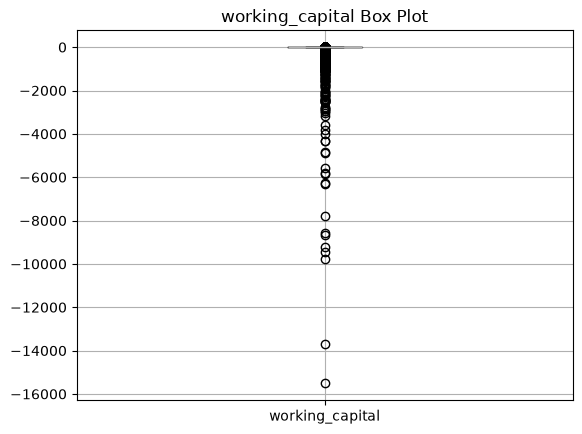

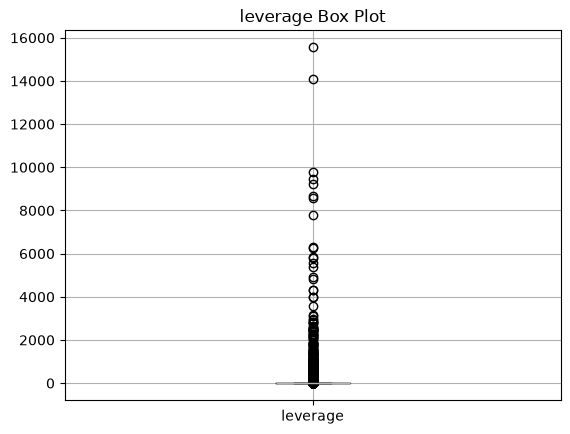

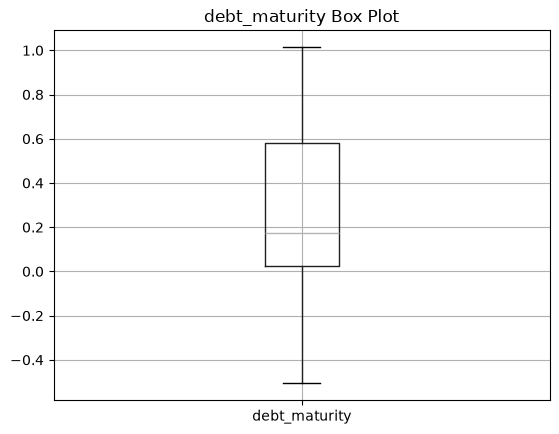

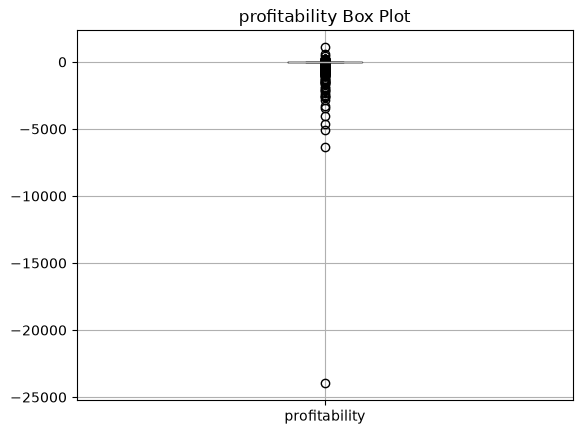

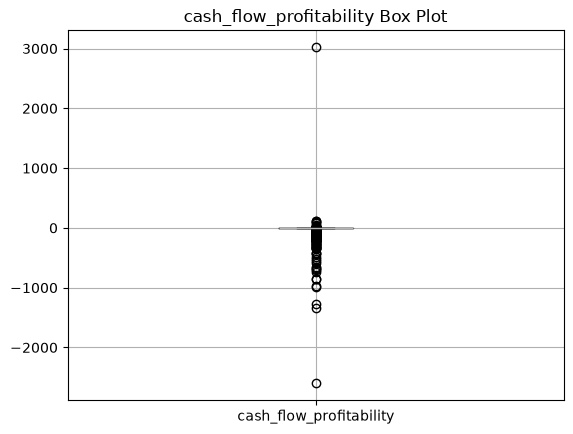

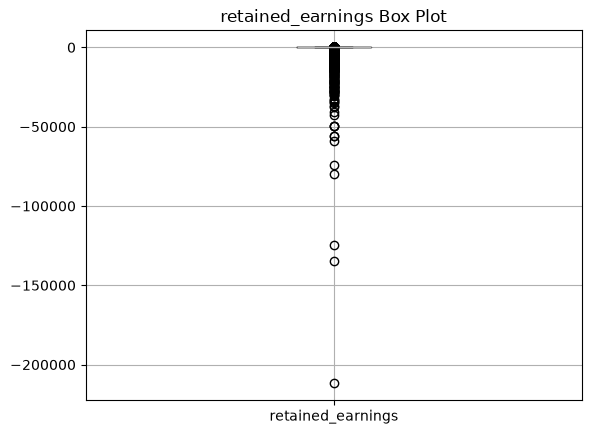

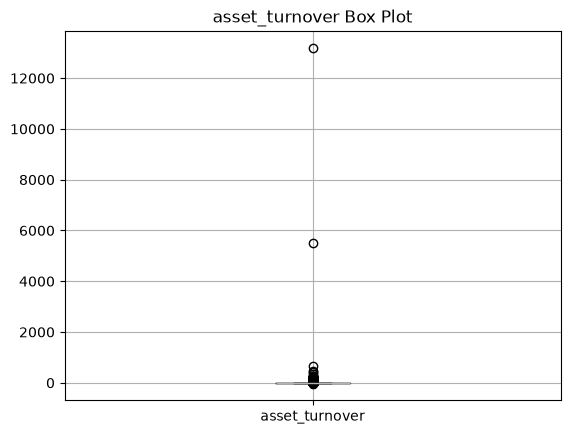

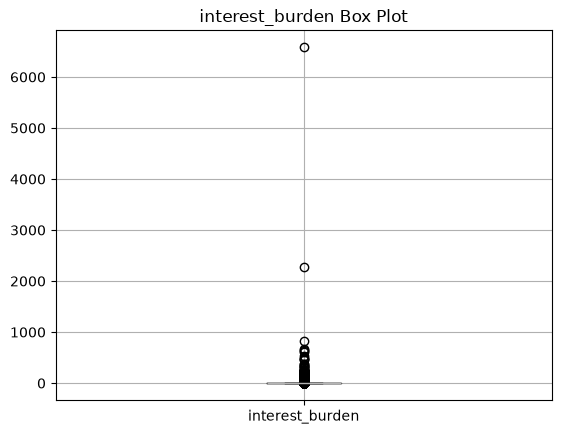

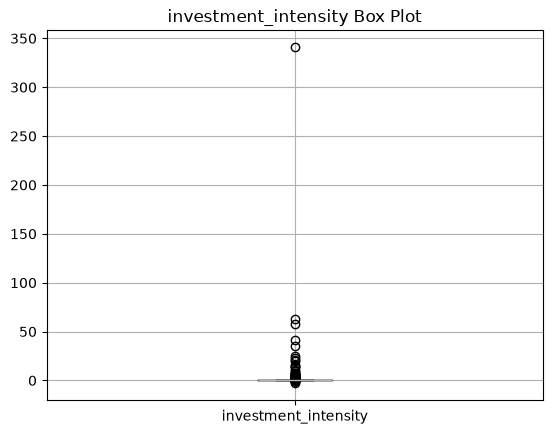

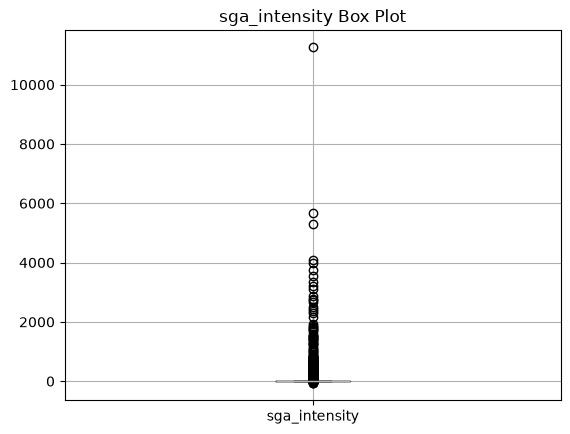

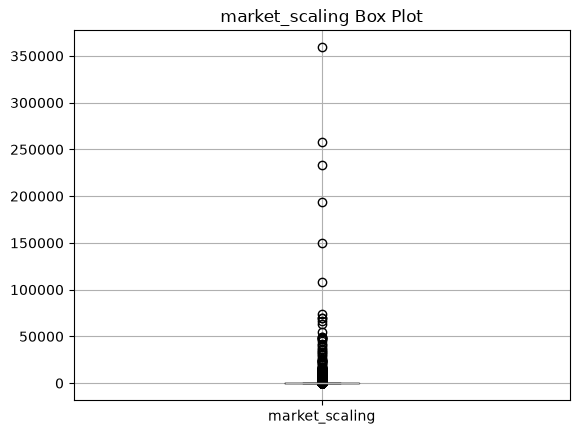

working_capital max/p99: 1.1302086508666158 min/p1: 822.3269647094265 822.3269647094265
leverage max/p99: 605.39445495209 min/p1: 0.0 0.0
debt_maturity max/p99: 1.0 min/p1: -inf -inf
profitability max/p99: 480.96453758017196 min/p1: 2504.9250354749515 2504.9250354749515
cash_flow_profitability max/p99: 7674.409215140764 min/p1: 567.0312417039979 567.0312417039979
retained_earnings max/p99: 172.22302330967773 min/p1: 980.4778916229179 980.4778916229179
asset_turnover max/p99: 2844.50161355118 min/p1: -inf -inf
interest_burden max/p99: 788.4875005588488 min/p1: -inf -inf
investment_intensity max/p99: 913.8683715653171 min/p1: -inf -inf
sga_intensity max/p99: 928.5542611163036 min/p1: -2706.440407686867 -2706.440407686867
market_scaling max/p99: 3603.766912442374 min/p1: 7.814518093825112e-05 7.814518093825112e-05


C:\Users\admin\AppData\Local\Temp\ipykernel_13060\3425668919.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max/p99 , "min/p1:" , min/p1, min/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_13060\3425668919.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max/p99 , "min/p1:" , min/p1, min/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_13060\3425668919.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max/p99 , "min/p1:" , min/p1, min/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_13060\3425668919.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max/p99 , "min/p1:" , min/p1, min/p1)


'\nThe majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. \nThis indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.\n'

In [119]:
outlier_description = final[features].describe()
#print(outlier_description) #investigating outliers to be able to do the next steps 

#Boxlplots for better visualisation
for feature in accounting_features:
    final.boxplot(column=feature)
    plt.title(feature + " Box Plot")
    plt.show()

for feature in accounting_features:
    p99 = train[feature].quantile(0.99)
    count = (train[feature] > p99).sum()
    max = train[feature].max()
    p1 = train[feature].quantile(0.01)
    min = train[feature].min()
    print(feature, "max/p99:" , max/p99 , "min/p1:" , min/p1, min/p1)

"""
The majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. 
This indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.
"""


In [120]:
#Now we windorize the extreme values for each feature by calculating the 1rst and 99th percentile & replace the extreme values with those calculations
#new dataframe just in case we need to go back
for feature in accounting_features:
 p1 = train[feature].quantile(0.01)
 p99 = train[feature].quantile(0.99)
 train[feature] = train[feature].clip(lower=p1, upper=p99)
 val[feature]   = val[feature].clip(lower=p1, upper=p99)
 test[feature]  = test[feature].clip(lower=p1, upper=p99)


#rebuildind the x and y splits after imputation & winsorization
x_train, y_train = train[x], train["distress"]
x_val,   y_val   = val[x],   val["distress"]
x_test,  y_test  = test[x],  test["distress"]

#Save final unscaled dataframes to csv for RandomForest & XGBoost models
train.to_csv("data/processed/unscaled_train_final.csv", index=False)
val.to_csv("data/processed/unscaled_val_final.csv", index=False)
test.to_csv("data/processed/unscaled_test_final.csv", index=False)

# fit scaler on TRAIN only 
scaler = StandardScaler()
scaler.fit(x_train[accounting_features])

# keep all columns, including missing indicators
X_train_scaled = x_train.copy()
X_val_scaled   = x_val.copy()
X_test_scaled  = x_test.copy()

# scale only accounting_features; keep indicator cols unchanged
X_train_scaled[accounting_features] = scaler.transform(x_train[accounting_features])
X_val_scaled[accounting_features]   = scaler.transform(x_val[accounting_features])
X_test_scaled[accounting_features]  = scaler.transform(x_test[accounting_features])

X_train_scaled.to_csv("data/processed/scaled_train_final.csv", index=False)
X_val_scaled.to_csv("data/processed/scaled_val_final.csv", index=False)
X_test_scaled.to_csv("data/processed/scaled_test_final.csv", index=False)

In [121]:
# Checking for data leakage (run on split dataframes, not feature matrices)
assert train["year"].max() < val["year"].min()
assert val["year"].max() < test["year"].min()

train_keys = set(zip(train["gvkey"], train["datadate"]))
val_keys   = set(zip(val["gvkey"], val["datadate"]))
test_keys  = set(zip(test["gvkey"], test["datadate"]))

assert train_keys.isdisjoint(val_keys)
assert train_keys.isdisjoint(test_keys)
assert val_keys.isdisjoint(test_keys)

In [122]:

#check mean and std of scaled data, check for missing values and inf values
#display(X_train_scaled.describe().T[['mean', 'std']])

#display(X_train_scaled.isnull().sum().sort_values(ascending=False).head(20))

#display(np.isinf(X_train_scaled).sum().sort_values(ascending=False).head(20))
#X_train_scaled.shape #multicollinearity check

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42) #Class imbalance handled here
lr.fit(X_train_scaled, y_train) #train model on scaled training data
y_pred = lr.predict(X_val_scaled)  #predict the target using the val dataset  (gives 0s and 1s) 
y_prob = lr.predict_proba(X_val_scaled)[:, 1] #predict the probability of the positibe class


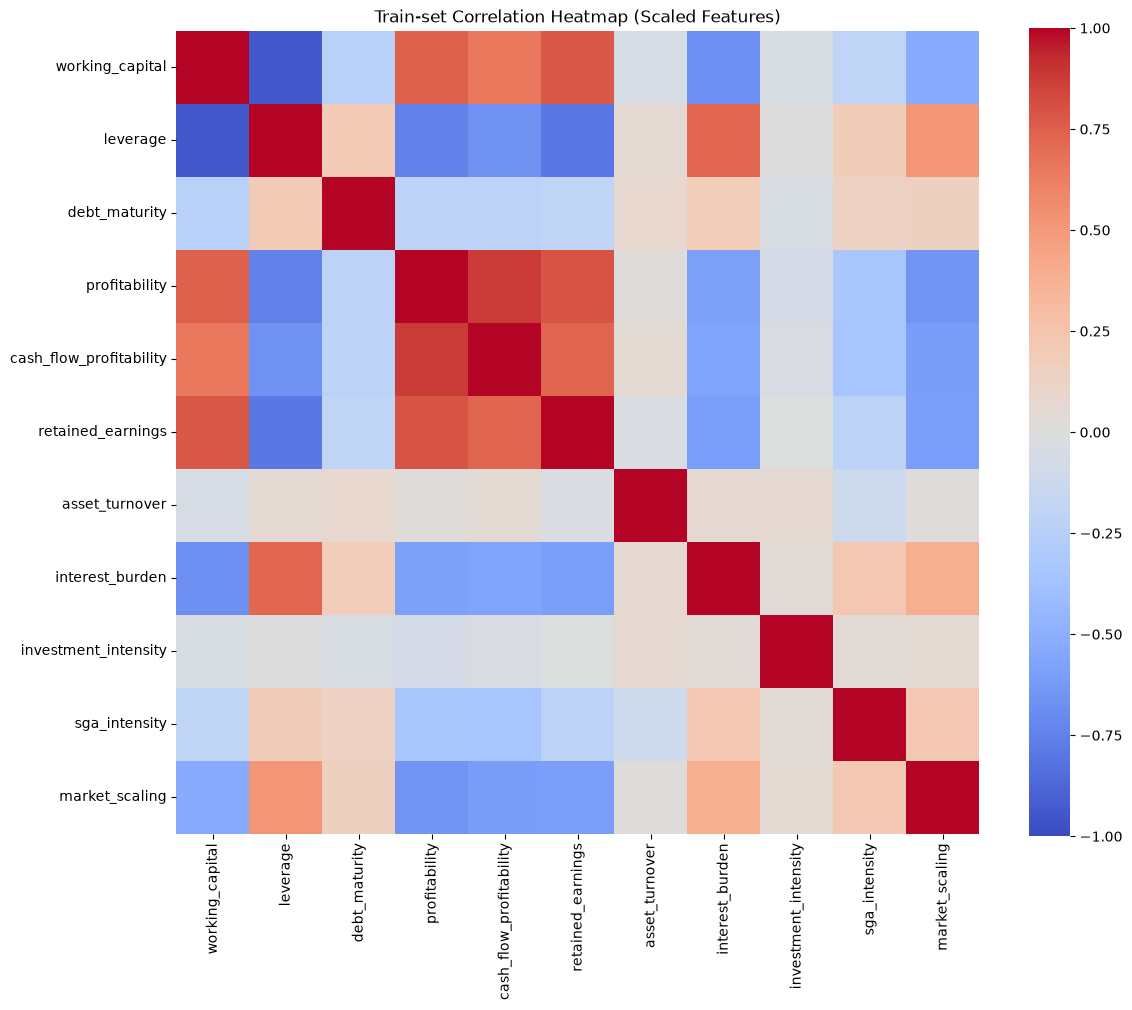

,var1,var2,abs_corr
1,working_capital,leverage,0.939156
37,profitability,cash_flow_profitability,0.877961
16,leverage,retained_earnings,0.792305
38,profitability,retained_earnings,0.791709
5,working_capital,retained_earnings,0.780495
3,working_capital,profitability,0.746433
14,leverage,profitability,0.744270
49,cash_flow_profitability,retained_earnings,0.726808
18,leverage,interest_burden,0.719693
7,working_capital,interest_burden,0.686467


,feature,VIF
1,leverage,7.996597
3,profitability,6.675851
0,working_capital,5.803474
4,cash_flow_profitability,4.713962
5,retained_earnings,3.893190
7,interest_burden,2.397401
10,market_scaling,2.002428
6,asset_turnover,1.844649
2,debt_maturity,1.732361
8,investment_intensity,1.381514


,feature,VIF
1,leverage,7.996597
3,profitability,6.675851
0,working_capital,5.803474


,feature,VIF


In [123]:

X_train_df = pd.DataFrame(
    x_train,                 
    columns=accounting_features,
    index=x_train.index
)

# Correlation heatmap
corr = X_train_scaled[accounting_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Train-set Correlation Heatmap (Scaled Features)")
plt.tight_layout()
plt.show()

# strongest absolute pairwise correlations
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
display(top_pairs.head(20))


# VIF table

vif_df = pd.DataFrame({
    "feature": X_train_df.columns,
    "VIF": [variance_inflation_factor(X_train_df.values, i)
            for i in range(X_train_df.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_df)

# Quick flags
display(vif_df[vif_df["VIF"] > 5])   # moderate concern
display(vif_df[vif_df["VIF"] > 10])  # serious concern

In [124]:
#Validation
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("PR AUC:", pr_auc)  

print("**********************")
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
print(cm)

#Best combination of metrics for this model given by : 
best = None
for threshold in np.arange(0.05, 0.96, 0.01):
    y_hat = (y_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat , zero_division=0)
    f1 =f1_score(y_val,y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division = 0)
    if best is None or f1 >= best[0]:
        best = (f1, p, r, threshold)

print("**********************")  
print("New values")
print("Best F1-Score/Precision/Recall/Threshold:", best)

best_threshold = best[3]
y_val_pred_best = (y_prob >= best_threshold).astype(int) #create vector with pred values 
cm2= confusion_matrix(y_val, y_val_pred_best)
print(cm2)

Accuracy: 0.7621188345561729
Precision: 0.006569602272727273
Recall: 0.7254901960784313
F1-score: 0.013021291571353158
ROC-AUC: 0.8043057583455008
PR AUC: 0.011479253330681836
**********************
Confusion Matrix:
[[17933  5595]
 [   14    37]]
**********************
New values
Best F1-Score/Precision/Recall/Threshold: (0.02952029520295203, 0.01818181818181818, 0.0784313725490196, np.float64(0.9500000000000002))
[[23312   216]
 [   47     4]]
